# Simulazione Dinamica di Segregazione

Per studiare l'emergere della polarizzazione dalle scelte individuali dei singoli nodi, abbiamo realizzato una simulazione basata sul **Schelling Segregation Model**.

Il modello parte da una rete random che mantiene la nostra distribuzione di grado e ne fa evolvere gli archi, in modo da non alterare i gradi dei singoli nodi.

Ad ogni step ogni nodo della rete valuta di cambiare un proprio link quando la frazione di nodi simili a cui è connesso è minore della soglia di soddisfazione. Quindi cercherà un nodo simile e disponibile a cui connettersi.

Per mantenere inalterata la distribuzione di grado, l'operazione di rewire può essere schematizzata come segue:

$$
(A,B);(C,D) \implies (A,C);(B,D)
$$

I nodi $A, B, C, D$ sono scelti rispettando i criteri:
- $A$ è un nodo **insoddisfatto**;
- $B$ è connesso ad $A$, ma appartenente ad una **classe diversa**;
- $C$ non è connesso ad $A$, ma appartenente alla **stessa classe** di $A$;
- $D$ è un nodo generico connesso con $C$, ma non connesso a $B$.

----
- *Questo modello è in grado di riprodurre i valori di polarizzazione osservati nella rete? Per quali valori della soglia?*
- *Si osserva la tendenza dei nodi a dividersi in gruppi separati, anche per soglie di soddisfazione fortemente minori del 50%?*
- *Come si confronta la simulazione rispetto a un null model Erdős-Rényi con le stesse proprietà topologiche?*

In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import json
from sys import stdout

from segregation_model import segregation_sim, satisfaction, nodes_all
from utils import *
from visualization_utils import *


THRESHOLD = 0.95      # soglia di soddisfazione
GRAPH_FILE = 'immigration_23.graphml'
OUT_PATH = JSON_DIR + f'dump_segregation_{GRAPH_FILE.replace(".graphml","")}_{int(THRESHOLD*100)}.json'

In [2]:
G = load_graph(DATA_DIR + GRAPH_FILE)

# Mappatura binaria dei gruppi (A=1, altri=0)
attr_map = np.array(G.vs['group'])
nodes = nodes_all(G)
nodes_satisfaction = np.array([
    satisfaction(n, G.neighbors(n), G.vs['group']) for n in nodes
])

n_nodes = G.vcount()
n_edges = G.ecount()
p_er    = n_edges / (n_nodes * (n_nodes - 1) / 2)   # probabilità per ER

# Composizione delle comunità (per assegnazione random proporzionale)
unique_groups, group_counts = np.unique(attr_map, return_counts=True)

## Metriche osservate sulla rete reale

Per visualizzare lo stato della simulazione abbiamo usato quattro metriche:
- **EI index**: ${i_A + i_B -e \over i_A + i_B + e}$

    dove $i_A, i_B$ sono i link interni alle comunità e $e$ sono i link ponte tra le comunità;

- **cross fraction**: frazione di link tra comunità rispetto ai link totali della rete;

- **satisfaction rate**: frazione dei nodi soddisfatti in accordo con la soglia selezionata in partenza;

- **segregation index**: media della frazione di nodi simili su tutti i nodi.

In [3]:
ei_obs               = ei_index(G, attr_map)
cross_fraction_obs   = 1 - cross_type_fraction(G, attr_map)
satisfaction_rate_obs = nodes_satisfaction[nodes_satisfaction >= THRESHOLD].size / nodes.size
segregation_index_obs = np.mean(nodes_satisfaction)

observed = {
    'ei_index':          ei_obs,
    'cross_fraction':    cross_fraction_obs,
    'satisfaction_rate': satisfaction_rate_obs,
    'segregation_index': segregation_index_obs,
}

print('Valori osservati sulla rete reale (target simulazione):')
for k, v in observed.items():
    print(f'  {k:25s}: {v:.4f}')

Valori osservati sulla rete reale (target simulazione):
  ei_index                 : -0.9340
  cross_fraction           : 0.9670
  satisfaction_rate        : 0.9120
  segregation_index        : 0.9771


## Simulazione sulla rete reale 

La funzione `segregation_sim` crea internamente una rete random che preserva la distribuzione di grado della rete reale, poi la fa evolvere secondo il modello di Schelling.

In [4]:
def run_simulation(G_input, threshold, max_satisfaction=satisfaction_rate_obs, label='sim', savefile_graphml=''):
    """Esegue la simulazione di segregazione e raccoglie le metriche ad ogni step.

    G_input         : grafo igraph di partenza 
    threshold       : soglia di soddisfazione
    max_satisfaction: criterio di stop
    label           : etichetta per il log
    Return: dizionario con le serie temporali delle quattro metriche
    """
    results = {k: [] for k in observed}
    statistic = None
    attr_map = np.array(G_input.vs['group'])

    print(f'[{label}] target : EI = {ei_obs:.4f}   Cross fraction = {cross_fraction_obs:.4f}\n')
    stdout.flush()

    G_sim = None
    statistic = {}

    for G_sim, statistic in segregation_sim(G_input, threshold, max_satisfaction=max_satisfaction):
        results['ei_index'].append(ei_index(G_sim, attr_map))
        results['cross_fraction'].append(1 - cross_type_fraction(G_sim, attr_map))
        results['satisfaction_rate'].append(statistic['satisfaction_rate'])
        results['segregation_index'].append(statistic['segregation_index'])

        if statistic['i_step']:
            print(f'[{label}] Step {statistic["i_step"]} \n '
                  f'Changed: {statistic["nodes_changed_step"]}  '
                  f'Satisfaction: {statistic["satisfaction_rate"]:.4f}  '
                  f'Index: {statistic["segregation_index"]:.4f}')
        else:
            print(f'[{label}] Simulazione avviata: ', end=' ')

        print(f'EI = {results["ei_index"][-1]:.4f}   '
              f'Cross fraction = {results["cross_fraction"][-1]:.4f}\n')
        stdout.flush()
    
    assert G_sim is not None, 'No simulation done'
    assert statistic, 'No simulation done'

    if not statistic['nodes_changed_step']:
        print(f'[{label}] Simulazione terminata in configurazione stabile al passo {statistic["i_step"]}')
        print(f'[{label}] Fallimenti totali: {len(list(filter(lambda x: x > 0, statistic["nodes_failures"])))}')
    else:
        print(f'[{label}] Simulazione fermata a satisfaction rate: {statistic["satisfaction_rate"]*100:.1f}%')
    
    if savefile_graphml:
        G_sim.write_graphml(savefile_graphml)
    return results

In [5]:
results_real = run_simulation(G, THRESHOLD, label='rete reale')

[rete reale] target : EI = -0.9340   Cross fraction = 0.9670

[rete reale] Simulazione avviata:  EI = -0.0127   Cross fraction = 0.5064

[rete reale] Step 1 
 Changed: 6263  Satisfaction: 0.3421  Index: 0.5691
EI = -0.2261   Cross fraction = 0.6131

[rete reale] Step 2 
 Changed: 4210  Satisfaction: 0.5577  Index: 0.7738
EI = -0.3009   Cross fraction = 0.6505

[rete reale] Step 3 
 Changed: 3583  Satisfaction: 0.6236  Index: 0.8235
EI = -0.3470   Cross fraction = 0.6735

[rete reale] Step 4 
 Changed: 3245  Satisfaction: 0.6591  Index: 0.8513
EI = -0.3820   Cross fraction = 0.6910

[rete reale] Step 5 
 Changed: 2983  Satisfaction: 0.6866  Index: 0.8688
EI = -0.4120   Cross fraction = 0.7060

[rete reale] Step 6 
 Changed: 2815  Satisfaction: 0.7043  Index: 0.8795
EI = -0.4348   Cross fraction = 0.7174

[rete reale] Step 7 
 Changed: 2598  Satisfaction: 0.7271  Index: 0.8931
EI = -0.4540   Cross fraction = 0.7270

[rete reale] Step 8 
 Changed: 2503  Satisfaction: 0.7371  Index: 0.9002

## Null model Erdős-Rényi

Per valutare se la dinamica osservata è una proprietà intrinseca del meccanismo di rewire o dipende dalla struttura della rete di partenza, confrontiamo con un **null model di Erdős-Rényi** inizializzato con i parametri della rete.

In [6]:
def build_er_null_model(G_real, seed=None):
    """Costruisce un grafo Erdős-Rényi con le stesse proprietà di base della rete reale
    e comunità assegnate casualmente con la stessa distribuzione.
    G_real : grafo reale
    seed   : seme random
    Return : grafo ER
    """
    if seed is not None:
        np.random.seed(seed)

    n = G_real.vcount()
    m = G_real.ecount()
    p = m / (n * (n - 1) / 2)

    # Grafo ER 
    G_er = ig.Graph.Erdos_Renyi(n=n, p=p)

    # Assegnazione random delle comunità rispettando le dimensioni originali
    group_labels_real = np.array(G_real.vs['group'])
    shuffled_groups   = np.random.permutation(group_labels_real)
    G_er.vs['group']  = shuffled_groups.tolist()

    return G_er


G_er = build_er_null_model(G, seed=42)

In [7]:
G_er = G_er.connected_components().giant()
print('G_er è stato connesso con perdita di:',  G.vcount() - G_er.vcount(), 'nodi')
if G.vcount() - G_er.vcount() > 20:
    print('Attenzione!')

G_er è stato connesso con perdita di: 6 nodi


In [8]:
results_er = run_simulation(G_er, THRESHOLD, label='Erdős-Rényi')

[Erdős-Rényi] target : EI = -0.9340   Cross fraction = 0.9670

[Erdős-Rényi] Simulazione avviata:  EI = -0.0074   Cross fraction = 0.5037

[Erdős-Rényi] Step 1 
 Changed: 9154  Satisfaction: 0.0377  Index: 0.5604
EI = -0.3905   Cross fraction = 0.6953

[Erdős-Rényi] Step 2 
 Changed: 8124  Satisfaction: 0.1460  Index: 0.7175
EI = -0.5932   Cross fraction = 0.7966

[Erdős-Rényi] Step 3 
 Changed: 7025  Satisfaction: 0.2615  Index: 0.8027
EI = -0.7093   Cross fraction = 0.8547

[Erdős-Rényi] Step 4 
 Changed: 6098  Satisfaction: 0.3590  Index: 0.8506
EI = -0.7794   Cross fraction = 0.8897

[Erdős-Rényi] Step 5 
 Changed: 5352  Satisfaction: 0.4374  Index: 0.8819
EI = -0.8260   Cross fraction = 0.9130

[Erdős-Rényi] Step 6 
 Changed: 4736  Satisfaction: 0.5022  Index: 0.9030
EI = -0.8617   Cross fraction = 0.9309

[Erdős-Rényi] Step 7 
 Changed: 4213  Satisfaction: 0.5571  Index: 0.9201
EI = -0.8874   Cross fraction = 0.9437

[Erdős-Rényi] Step 8 
 Changed: 3689  Satisfaction: 0.6122  Ind

In [9]:
dump = {
    'file':       GRAPH_FILE,
    'threshold':  THRESHOLD,
    'observed':   observed,
    'sim_real':   results_real,
    'sim_er':     results_er,
}

with open(OUT_PATH, 'w') as f:
    json.dump(dump, f, indent=2)

print(f'Risultati salvati in: {OUT_PATH}')

Risultati salvati in: /home/lore/PyProjects/Networks/AVRC_FinnishTwittersphereProject/Consegna finale/Data/JSON/dump_segregation_immigration_23_95.json


## Risultati delle simulazioni

Mostriamo di seguito i risultati delle simulazioni per tre valori di threshold: 0.35, 0.65, 0.95. Riportiamo il valore osservato nella nostra rete e l'andamento delle simulazioni a partire dal modello nullo (ER) e dalla rete reale.

In [10]:
def plot_comparison(results: dict):
    """Genera la figura di confronto tra simulazione reale, ER e valori osservati."""
    observed = results['observed']
    results_real = results['sim_real']
    results_er = results['sim_er']
    threshold = results['threshold']
    metrics = ['ei_index', 'cross_fraction', 'satisfaction_rate', 'segregation_index']
    titles  = ['EI Index', 'Cross Fraction', 'Satisfaction Rate', 'Segregation Index']

    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_4, sharex=True)
    fig.suptitle(
        f'Confronto Simulazioni con soglia = {threshold}',
        fontsize=FONTSIZE_SUPTITLE
    )

    for ax, metric, title in zip(axes.flat, metrics, titles):
        t_real = range(len(results_real[metric]))
        t_er   = range(len(results_er[metric]))

        ax.plot(t_real, results_real[metric], label='Sim. rete reale',  color='steelblue', linewidth=2)
        ax.plot(t_er,   results_er[metric],   label='Sim. Erdős-Rényi', color='darkorange', linewidth=2)
        ax.axhline(observed[metric], color='crimson', linestyle=':', linewidth=1.5,
                   label=f'Osservato = {observed[metric]:.3f}')
        ax.axvline(len(results_er['ei_index'])-1, linestyle='--', color='grey', alpha=0.5)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Step')
        ax.set_ylabel(title)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


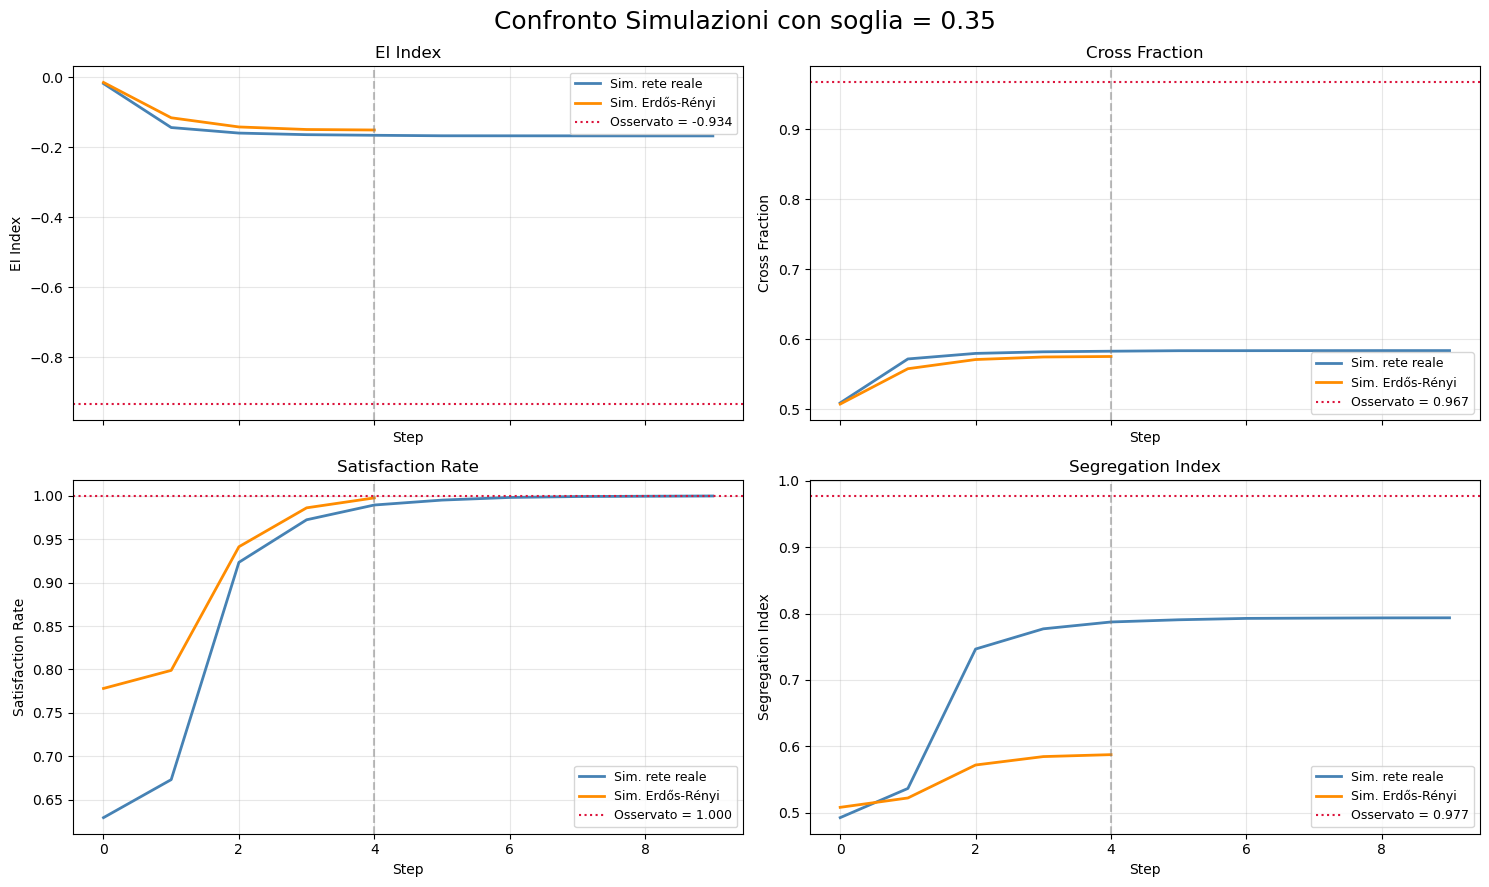

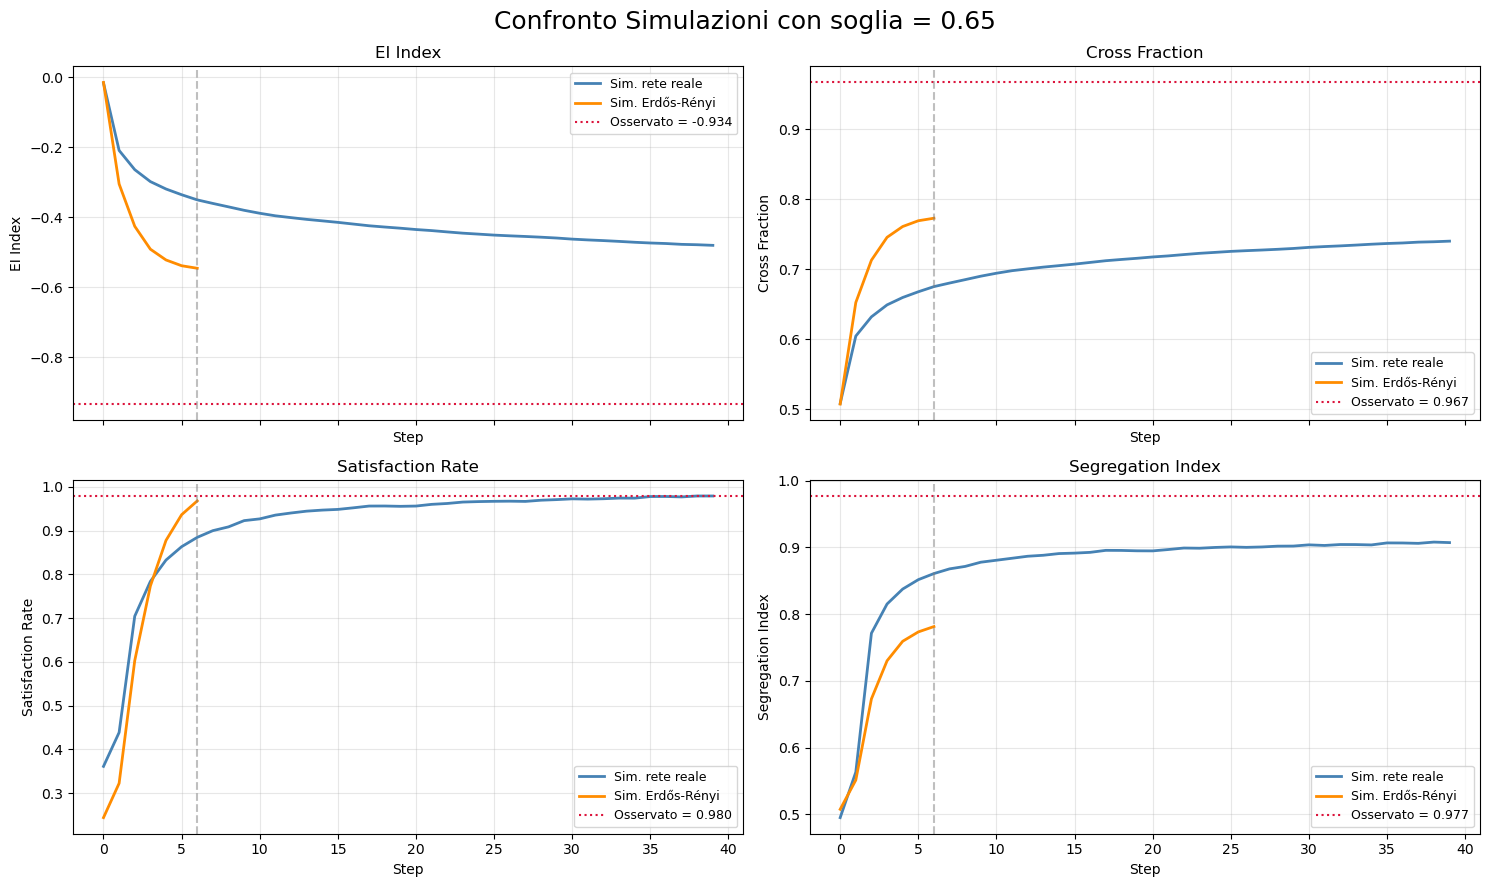

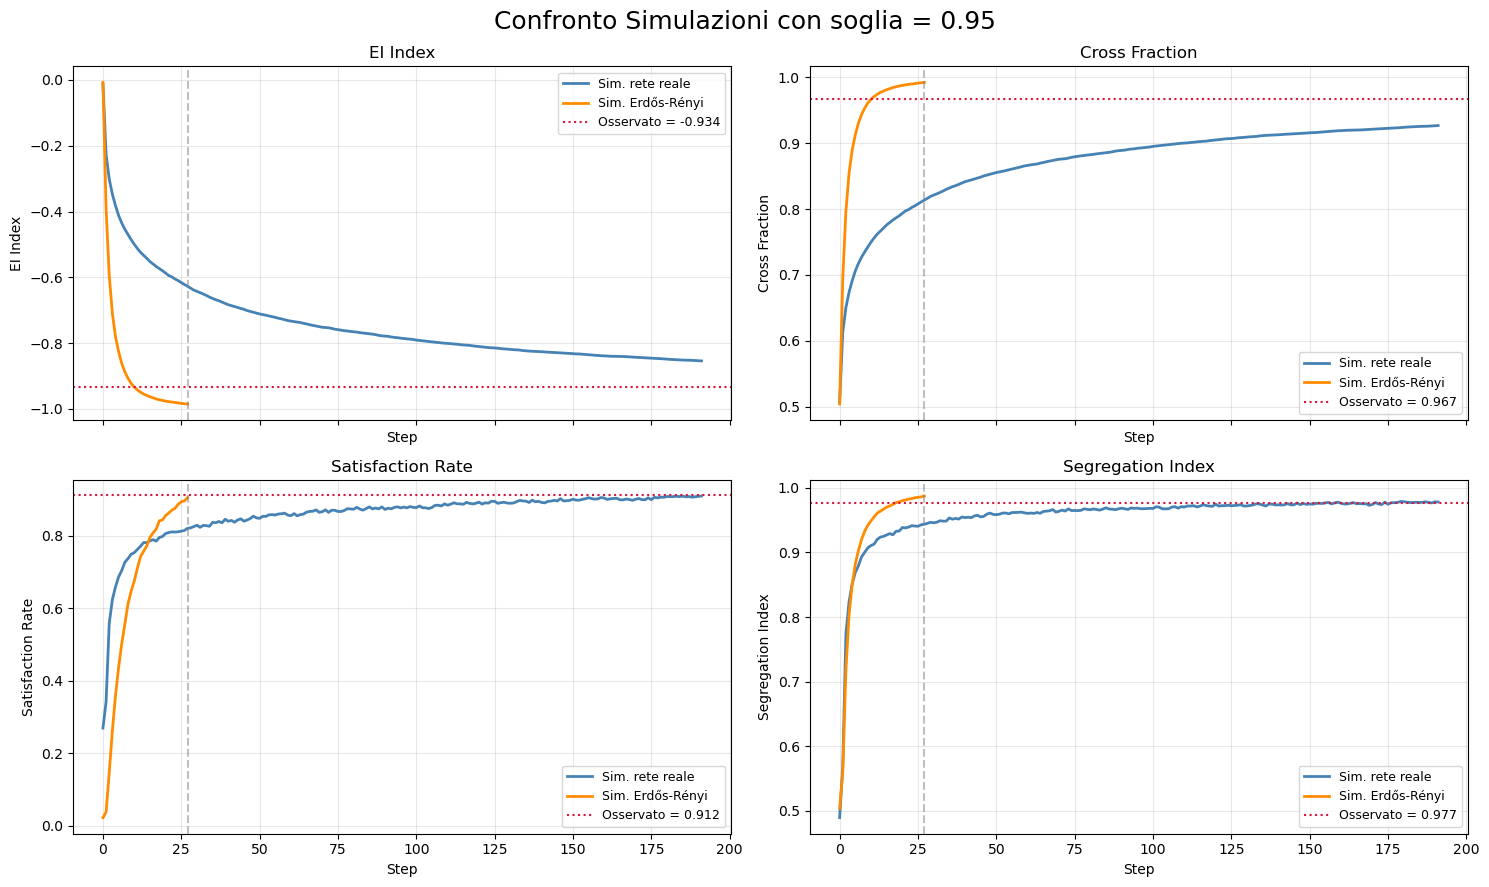

In [11]:
results_all = [json.load(open(JSON_DIR + dump_name)) 
                for dump_name in 
                ['dump_segregation_immigration_23_35.json', 'dump_segregation_immigration_23_65.json', 'dump_segregation_immigration_23_95.json']]
for result in results_all:
    plot_comparison(result)

Da tutti i grafici notiamo che la simulazione effettuata su modello nullo non presenta alcuna polarizzazione misurata tramite ei-index e cross-fraction.
Notiamo come per i diversi valori di threshold:
- per 0.35: l'indice di segregazione (0.8) risulta maggiore della soglia impostata, mostrando il paradosso di Shelling. Però la polarizzazione è bassa rispetto al valore osservato nella rete di partenza. Nonostante ciò l'indice di segregazione.
- per 0.65: verifichiamo l'aumento della polarizzazione rispetto alla simulazione precedente.
- per 0.95: le metriche diventano confrontabili con quelle osservate nella rete originale. 

## Confronto dei risultati

Confrontiamo i valori di cross-faction finali tra le simulazioni effettuate.

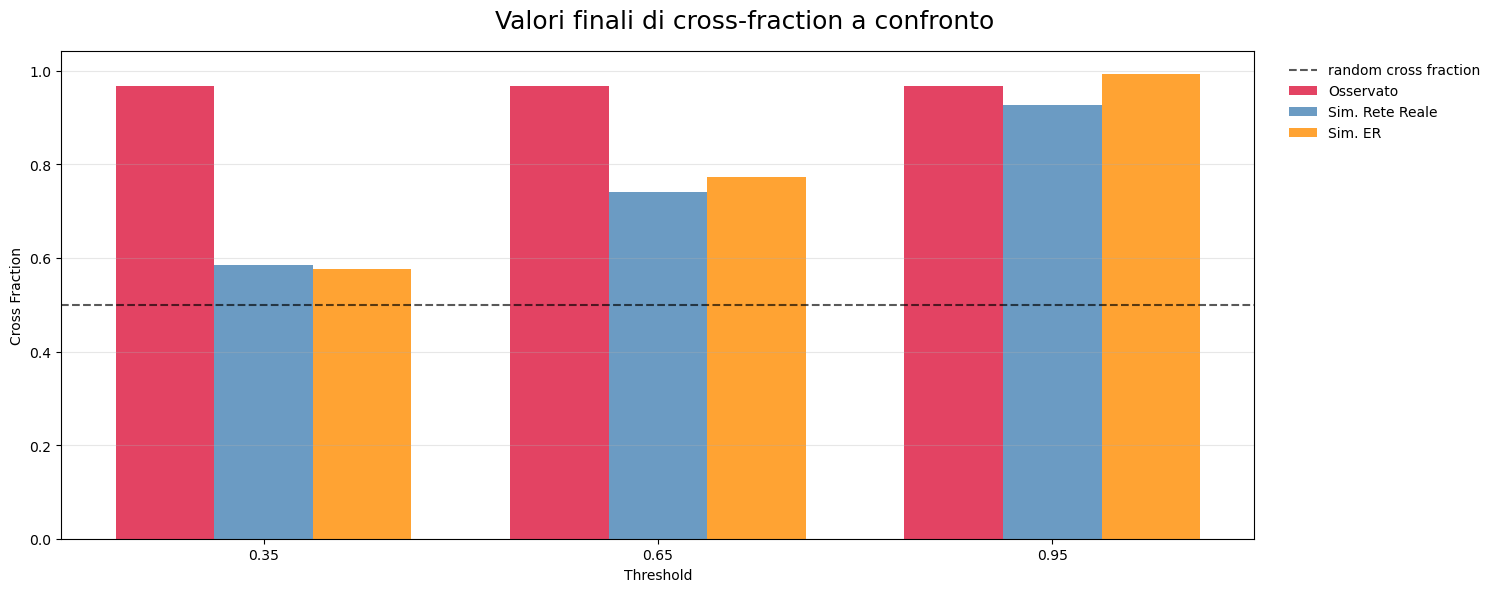

In [12]:
fig2, ax = plt.subplots(figsize=FIGSIZE_LARGE)

# plot risultati al variare della soglia simulata: 0.35, 0.65, 0.95
x = np.arange(len(results_all))

width  = 0.25
bars_obs  = ax.bar(x - width,  [sim_result['observed']['cross_fraction']   for sim_result in results_all],
                    width, label='Osservato',       color='crimson',    alpha=0.8)
bars_real = ax.bar(x,          [sim_result['sim_real']['cross_fraction'][-1]    for sim_result in results_all],
                    width, label='Sim. Rete Reale', color='steelblue',  alpha=0.8)
bars_er   = ax.bar(x + width,  [sim_result['sim_er']['cross_fraction'][-1]    for sim_result in results_all],
                    width, label='Sim. ER',         color='darkorange', alpha=0.8)

ax.axhline(0.5, color='black', linestyle='--', alpha=0.65, label='random cross fraction')
ax.set_xticks(x)
ax.set_xticklabels([str(result_sim['threshold']) for result_sim in results_all])
ax.set_ylabel('Cross Fraction')
ax.set_xlabel('Threshold')
fig2.suptitle(f'Valori finali di cross-fraction a confronto', fontsize=FONTSIZE_SUPTITLE)
ax.legend(frameon = False, bbox_to_anchor=(1.2,1), loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

La polarizazione confrontabile con la nostra rete emerge per valori di soglia superiori al 95%.

## Conclusioni

Osserviamo come la simulazione converga ad uno stato stazionario ad ogni iterazione indipendentemente dalla soglia, riuscendo quindi a soddisfare tutti i nodi.

Concludiamo che il valore di polarizzazione osservato nella rete (**EI index** o **cross fraction**) può essere spiegato da:
- fenomeni non descritti dal modello, ad esempio l'organizzazione in gruppi politici strutturati;
- presenza di utenti che hanno una forte tendenza a ricerare individui simili a loro.

Il confronto con il **null model Erdős-Rényi** permette di valutare che la polarizzazione osservata non è una proprietà emergente dal meccanismo di rewire soltanto, ma ha una forte dipendenza dalla topologia di partenza.